# Finance Instruction Dataset Preparation Pipeline

## Objective

This notebook builds a curated finance-oriented instruction dataset for conversational supervised fine-tuning.

The goal is to transform a raw instruction-response dataset into a cleaner training corpus by applying domain filtering, reasoning-quality checks, stratified splitting, and chat-template formatting.

The final output is designed to be directly usable in downstream fine-tuning workflows.

---

## Dataset Source

The dataset is based on the Hugging Face repository `heladell/Finance_DeepSeek-R1-Distill-dataset`.

It contains finance-related instruction-response pairs, including responses with `<think>` reasoning traces generated by a DeepSeek-R1 teacher model.

---

## Preparation Strategy

The preprocessing strategy is designed around four principles:

- domain relevance: keep finance, actuarial, and quantitative reasoning samples
- data quality: remove duplicated, incomplete, or irrelevant examples
- reasoning quality: filter low-quality `<think>` traces when explicit reasoning is present
- training compatibility: format the corpus into a Qwen-compatible conversational SFT structure

---

## Scope

This notebook focuses on dataset preparation only.

Model training, evaluation, deployment, and monitoring are handled in downstream stages.

---

## Output Artifacts

The pipeline exports:

- SFT datasets in JSONL format
- intermediate datasets in Parquet format
- preprocessing reports in CSV format
- visual diagnostics for reporting

---

## Authors

Ashot Akopov  
Henri Bardonnaut  
Tristan Chambert

# 1. Environment Setup

This section initializes the environment and imports the required dependencies.

In [133]:
import re
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 2. Dataset Loading

This section loads the source dataset and converts it into a Pandas DataFrame.

In [134]:
dataset = load_dataset(
    "heladell/Finance_DeepSeek-R1-Distill-dataset",
    split="train"
)

In [135]:
df = dataset.to_pandas()

In [136]:
pipeline_stats = []

pipeline_stats.append({
    "step": "Initial dataset",
    "samples": len(df)
})

# 3. Exploratory Data Analysis

This section performs an initial inspection

## 3.1 Dataset Structure

In [137]:
df.columns

Index(['conversation_id', 'instruction', 'response', 'conversations',
       'gen_input_configs', 'gen_response_configs', 'intent', 'knowledge',
       'difficulty', 'difficulty_generator', 'input_quality',
       'quality_explanation', 'quality_generator', 'task_category',
       'other_task_category', 'task_category_generator', 'language'],
      dtype='object')

In [138]:
df.shape

(26952, 17)

In [139]:
df = df.drop_duplicates(
    subset=["instruction", "response"]
)

In [140]:
print(f"Remaining samples: {len(df)}")

Remaining samples: 23972


In [141]:
pipeline_stats.append({
    "step": "Deduplication",
    "samples": len(df)
})

## 3.2 Missing Responses

In [142]:
has_response = df["response"].notna().sum()
has_response

np.int64(23971)

In [143]:
df = df[df['response'].notna()]

In [144]:
print(f"Remaining samples: {len(df)}")

Remaining samples: 23971


In [145]:
pipeline_stats.append({
    "step": "Remove missing responses",
    "samples": len(df)
})

## 3.3 Task Categories

In [146]:
per_task = df["task_category"].value_counts().to_frame().reset_index()
per_task

,task_category,count
0,Math,20389
1,Data analysis,1040
2,Information seeking,996
3,Reasoning,606
4,Planning,444
5,Coding & Debugging,390
6,Advice seeking,64
7,Editing,30
8,Brainstorming,7
9,Role playing,1


In [147]:
excluded_categories = (
    "Coding & Debugging",
    "Advice seeking",
    "Editing",
    "Brainstorming",
    "Role playing",
    "Creative writing"
)

df = df[~df["task_category"].isin(excluded_categories)]

In [148]:
print(f"Remaining samples: {len(df)}")

Remaining samples: 23478


In [149]:
pipeline_stats.append({
    "step": "Relevant category filtering",
    "samples": len(df)
})

## 3.4 Language Filtering

In [150]:
per_lan = df["language"].value_counts().to_frame().reset_index()
per_lan

,language,count
0,EN,23219
1,LA,173
2,AZ,20
3,DA,18
4,DE,7
5,RO,7
6,CA,4
7,ST,4
8,EO,4
9,YO,4


In [151]:
df = df[df["language"] == "EN"]

In [152]:
print(f"Remaining samples: {len(df)}")

Remaining samples: 23219


In [153]:
pipeline_stats.append({
    "step": "English-only filtering",
    "samples": len(df)
})

# 4. Financial Domain Filtering

This section keeps samples that are relevant to finance using simple, auditable heuristics.

## 4.1 Finance-Related Keyword Filtering

The filtering step relies on finance-related keywords covering corporate finance, financial markets, banking, insurance, accounting, macroeconomics, and actuarial science.

This keyword-based filter is intentionally simple, interpretable, and auditable.

It is used as a conservative preprocessing step rather than as a semantic classifier, and may still produce false positives or false negatives.

In [154]:
def is_finance_related(row):

    finance_keywords = [

        # Corporate finance
        "ebitda",
        "cash flow",
        "free cash flow",
        "fcf",
        "capex",
        "valuation",
        "revenue",
        "profit",
        "margin",
        "dividend",

        # Financial markets
        "bond",
        "equity",
        "stock",
        "portfolio",
        "asset",
        "liability",
        "yield",
        "volatility",
        "option",
        "derivative",
        "credit",
        "interest rate",
        "inflation",
        "market risk",

        # Banking and insurance
        "loan",
        "mortgage",
        "insurance",
        "solvency",
        "scr",
        "actuarial",
        "taeg",

        # Accounting and financial analysis
        "balance sheet",
        "income statement",
        "financial statement",
        "return on equity",
        "roe",
        "roa",

        # Macroeconomics
        "gdp",
        "federal reserve",
        "fed",
        "central bank",
        "monetary policy"
    ]

    text = (
        str(row["instruction"]) + " " +
        str(row["response"]) + " " +
        str(row.get("intent", "")) + " " +
        str(row.get("knowledge", ""))
    ).lower()

    return any(
        keyword in text
        for keyword in finance_keywords
    )


In [155]:
df["finance_related"] = df.apply(
    is_finance_related,
    axis=1
)

## 4.2 Filtering Diagnostics

The cross-tabulation below checks how finance-related samples are distributed across task categories.

In [156]:
finance_filtering_table = pd.crosstab(
    df["task_category"],
    df["finance_related"],
    margins=True
)

finance_filtering_table

finance_related,False,True,All
task_category,,,
Data analysis,114,925,1039
Information seeking,162,826,988
Math,5529,14611,20140
Planning,48,395,443
Reasoning,109,497,606
All,5962,17254,23216


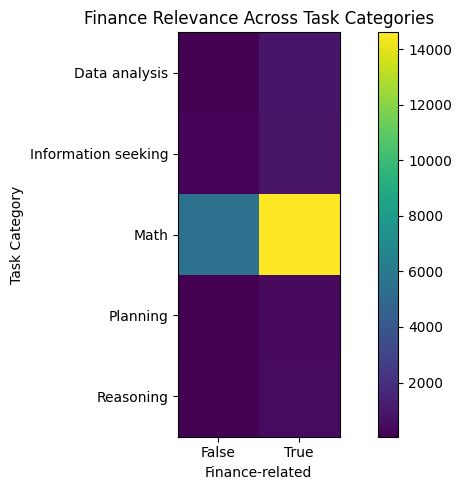

In [157]:
finance_filtering_matrix = finance_filtering_table.iloc[:-1, :-1]

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(finance_filtering_matrix)

ax.set_title("Finance Relevance Across Task Categories")
ax.set_xlabel("Finance-related")
ax.set_ylabel("Task Category")

ax.set_xticks(range(len(finance_filtering_matrix.columns)))
ax.set_xticklabels(finance_filtering_matrix.columns)

ax.set_yticks(range(len(finance_filtering_matrix.index)))
ax.set_yticklabels(finance_filtering_matrix.index)

fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

fig.savefig("finance_filtering_heatmap.png", bbox_inches="tight")

## 4.3 Domain Filtering

Samples unrelated to finance are removed.

`Math` samples are preserved because they remain useful for numerical and symbolic reasoning.

In [158]:
df = df[
    (df["task_category"] == "Math")
    |
    (df["finance_related"])
]

In [159]:
print(f"Remaining samples: {len(df)}")

Remaining samples: 22786


In [160]:
pipeline_stats.append({
    "step": "Finance filtering",
    "samples": len(df)
})

# 5. Reasoning Quality Filtering

This section detects explicit reasoning traces and filters low-quality reasoning examples.

## 5.1 Reasoning Trace Detection


In [161]:
def has_think(response):

    if response is None:
        return False

    return bool(
        re.search(
            r"<think>.*?</think>",
            str(response),
            flags=re.DOTALL
        )
    )


df["has_think"] = df["response"].apply(has_think)

In [162]:
df["has_think"].value_counts().to_frame().reset_index()

,has_think,count
0,True,17038
1,False,5748


## 5.2 Reasoning Quality Assessment

A lightweight heuristic filter is applied to remove reasoning traces that are too short, too noisy, poorly structured, or missing a usable final answer.

In [163]:
# Extract reasoning traces enclosed within <think> tags

def extract_think(response):
    """
    Extract reasoning content from <think> tags.
    """
    match = re.search(
        r"<think>(.*?)</think>",
        str(response),
        flags=re.DOTALL
    )
    return match.group(1).strip() if match else ""


# Remove reasoning traces and preserve the final answer

def remove_think(response):
    """
    Remove <think> blocks from the response.
    """
    return re.sub(
        r"<think>.*?</think>",
        "",
        str(response),
        flags=re.DOTALL
    ).strip()


# Evaluate reasoning trace quality for training

def is_good_reasoning(row):
    """
    Evaluate whether a reasoning trace is suitable for training.
    """

    instruction = str(row["instruction"])
    response = str(row["response"])

    think = extract_think(response)
    final_answer = remove_think(response)

    instruction_words = len(instruction.split())
    think_words = len(think.split())
    final_answer_words = len(final_answer.split())

    # Avoid division by zero
    think_instruction_ratio = think_words / max(instruction_words, 1)

    noise_words = [
        "wait",
        "maybe",
        "hmm",
        "perhaps",
        "let me think",
        "actually"
    ]

    noise_score = sum(
        think.lower().count(word)
        for word in noise_words
    )

    has_structure = any(
        marker in think.lower()
        for marker in [
            "first",
            "then",
            "finally",
            "therefore",
            "step",
            "1.",
            "2.",
            "so,"
        ]
    )

    has_formula = any(
        symbol in think
        for symbol in ["=", "+", "-", "/", "*", "%"]
    )

    has_final_answer = final_answer_words > 20

    if think_words == 0:
        return False

    if think_words < 60:
        return False

    if not has_final_answer:
        return False

    if noise_score > 12:
        return False

    if think_instruction_ratio > 20:
        return False

    if think_instruction_ratio <= 4:
        return noise_score <= 8

    if 4 < think_instruction_ratio <= 10:
        return (
            noise_score <= 5
            and (has_structure or has_formula)
        )

    if 10 < think_instruction_ratio <= 20:
        return (
            noise_score <= 2
            and has_structure
            and has_formula
        )

    return False

In [164]:
df["good_reasoning"] = df.apply(
    is_good_reasoning,
    axis=1
)

In [165]:
reasoning_quality_table = pd.crosstab(
    df["has_think"],
    df["good_reasoning"],
    margins=True
)

reasoning_quality_table

good_reasoning,False,True,All
has_think,,,
False,5748,0,5748
True,8999,8039,17038
All,14747,8039,22786


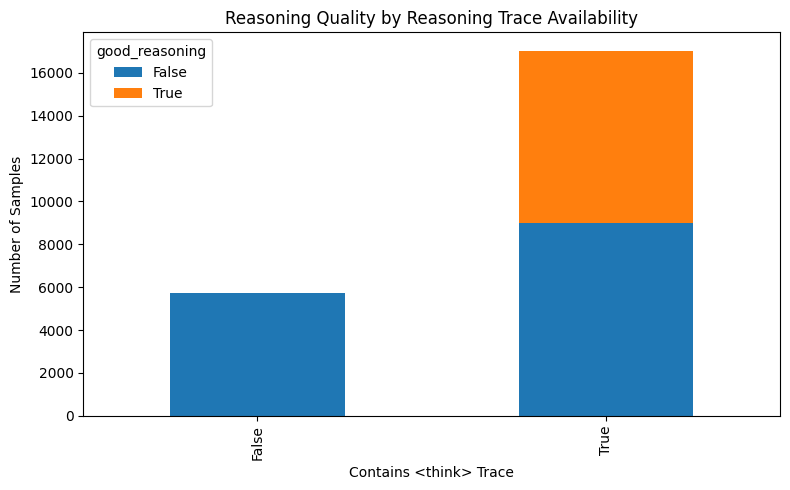

In [166]:
reasoning_quality_matrix = reasoning_quality_table.iloc[:-1, :-1]

ax = reasoning_quality_matrix.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("Reasoning Quality by Reasoning Trace Availability")
ax.set_xlabel("Contains <think> Trace")
ax.set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("reasoning_quality_distribution.png", bbox_inches="tight")

## 5.3 Qualitative Validation

A manual inspection is performed on both high-quality and low-quality reasoning samples.

In [167]:
good_examples = df[
    df["good_reasoning"]
]

good_examples.sample(5)[
    ["instruction", "response"]
]

,instruction,response
17737,### Park Entrance Fee\nThe park entrance fee i...,"<think>\nFirst, I need to determine the number..."
15055,### Overview of the Analysis\nThe cash flow pr...,"<think>\nFirst, I need to identify the key com..."
11878,h-law Ken's farm produces 3000 eggs per day. L...,"<think>\nFirst, I need to determine how many e..."
13068,The price of your mutual fund is directly prop...,"<think>\nFirst, I need to determine the total ..."
15128,What is the remaining balance of a credit card...,"<think>\nFirst, I need to determine the remain..."


In [168]:
bad_examples = df[
    (df["has_think"])
    & (~df["good_reasoning"])
]

bad_examples.sample(5)[
    ["instruction", "response"]
]

,instruction,response
14117,The base of a right triangle is 5 cms and the ...,"<think>\nOkay, so I have this problem here abo..."
9107,"In the context of probability theory, which of...","<think>\nOkay, so I have this question about c..."
3713,A ball is thrown upward from the surface of th...,"<think>\nOkay, so I have this problem where a ..."
2654,# INEGI offering an algebra-based review cours...,"<think>\nOkay, so I have this question here: ""..."
17026,Why is quantum mechanics helpful for modeling ...,"<think>\nOkay, so I have this question about w..."


Samples without explicit reasoning are preserved. Samples containing `<think>` traces are kept only when the reasoning-quality heuristic validates them.

In [169]:
df = df[
    (~df["has_think"])
    | (df["good_reasoning"])
]

In [170]:
print(f"Remaining samples: {len(df)}")

Remaining samples: 13787


In [171]:
pipeline_stats.append({
    "step": "Reasoning quality filtering",
    "samples": len(df)
})

# 6. Final Dataset Construction

This section prepares the cleaned dataset, train/test split, conversational format, and exports.

In [172]:
df_filtered = df.copy()

In [173]:
# Build preprocessing statistics summary

stats_df = pd.DataFrame(pipeline_stats)

# Retention rate relative to the initial dataset
stats_df["retention_rate"] = (
    100 * stats_df["samples"]
    / stats_df["samples"].iloc[0]
).round(2)

# Number of removed samples at each step
stats_df["removed_samples"] = (
    stats_df["samples"].shift(1) - stats_df["samples"]
).fillna(0).astype(int)

# Retention rate relative to the previous preprocessing step
stats_df["step_retention_rate"] = (
    100 * stats_df["samples"]
    / stats_df["samples"].shift(1)
).fillna(100).round(2)

stats_df

,step,samples,retention_rate,removed_samples,step_retention_rate
0,Initial dataset,26952,100.00,0,100.00
1,Deduplication,23972,88.94,2980,88.94
2,Remove missing responses,23971,88.94,1,100.00
3,Relevant category filtering,23478,87.11,493,97.94
4,English-only filtering,23219,86.15,259,98.90
5,Finance filtering,22786,84.54,433,98.14
6,Reasoning quality filtering,13787,51.15,8999,60.51


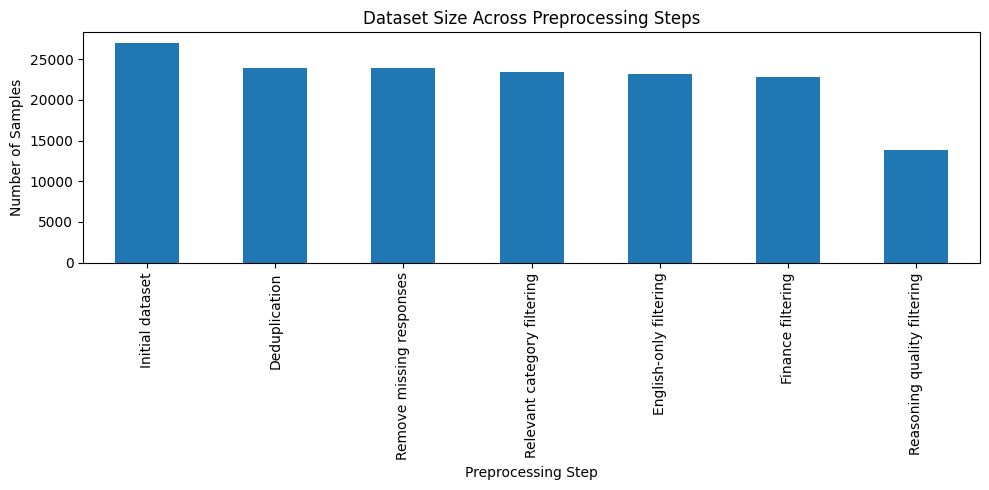

In [174]:
ax = stats_df.plot(
    x="step",
    y="samples",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Dataset Size Across Preprocessing Steps")
ax.set_xlabel("Preprocessing Step")
ax.set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig(
    "dataset_filtering_pipeline.png",
    bbox_inches="tight"
)

# 6.1 Clean Dataset Assembly

Only the columns required for analysis, quality checks, and training preparation are preserved.

In [175]:
# Columns preserved for analysis and training preparation

clean_columns = [
    "instruction",
    "response",
    "task_category",
    "difficulty",
    "input_quality",
    "has_think",
    "finance_related",
    "good_reasoning"
]

df_clean = df_filtered[clean_columns].copy()

## 6.2 Preprocessing Report and Visual Diagnostics

This section summarizes the evolution of the dataset across preprocessing steps and provides visual diagnostics for the final curated dataset.

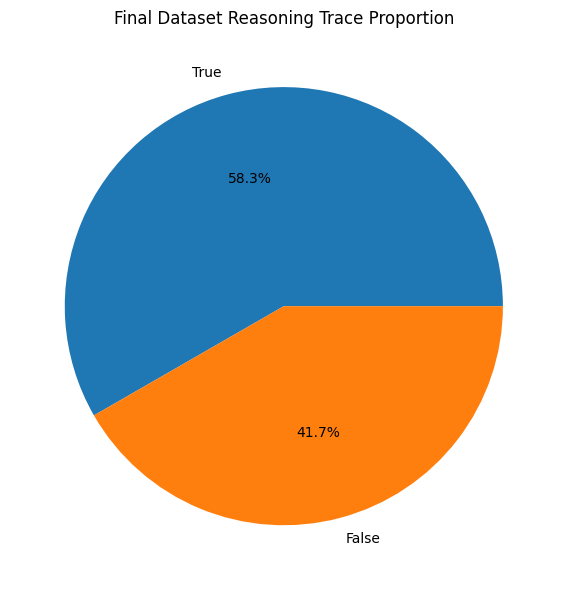

In [176]:
ax = df_clean["has_think"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6, 6)
)

ax.set_title("Final Dataset Reasoning Trace Proportion")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("final_reasoning_proportion.png", bbox_inches="tight")

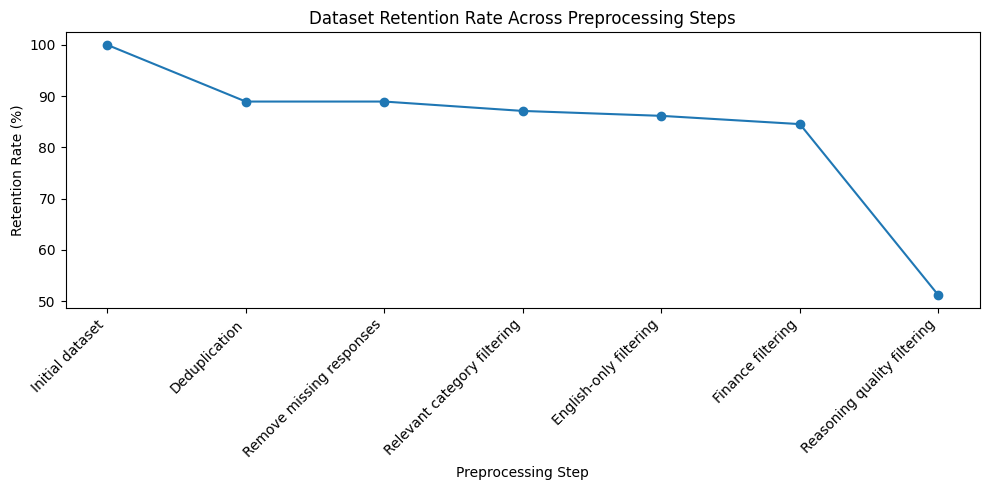

In [177]:
ax = stats_df.plot(
    x="step",
    y="retention_rate",
    kind="line",
    marker="o",
    legend=False,
    figsize=(10, 5)
)

ax.set_title("Dataset Retention Rate Across Preprocessing Steps")
ax.set_xlabel("Preprocessing Step")
ax.set_ylabel("Retention Rate (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("dataset_retention_rate.png", bbox_inches="tight")

## 6.3 Train/Test Split

The split uses stratified sampling based on reasoning availability and difficulty level.

In [178]:
df_clean["difficulty"].value_counts().to_frame().reset_index()

,difficulty,count
0,medium,8809
1,easy,4130
2,hard,779
3,very easy,53
4,very hard,1


Rare difficulty levels are merged to stabilize the stratified split.

In [179]:
def clean_difficulty(x):

    if x in ["very easy"]:
        return "easy"

    if x in ["very hard"]:
        return "hard"

    return x


df_clean["difficulty_clean"] = (
    df_clean["difficulty"]
    .apply(clean_difficulty)
)

In [180]:
df_clean["difficulty_clean"].value_counts()

,count
difficulty_clean,
medium,8809
easy,4183
hard,780


In [181]:
df_clean["stratify_col"] = (
    df_clean["has_think"].astype(str)
    + "_"
    + df_clean["difficulty_clean"].astype(str)
)

In [182]:
df_clean["stratify_col"].value_counts()

,count
stratify_col,
True_medium,4465
False_medium,4344
True_easy,3499
False_hard,709
False_easy,684
True_hard,71
False_None,11
True_None,4


In [183]:
df_train, df_test = train_test_split(
    df_clean,
    test_size=0.1,
    random_state=42,
    stratify=df_clean["stratify_col"]
)

In [184]:
print(df_train.shape)
print(df_test.shape)

(12408, 10)
(1379, 10)


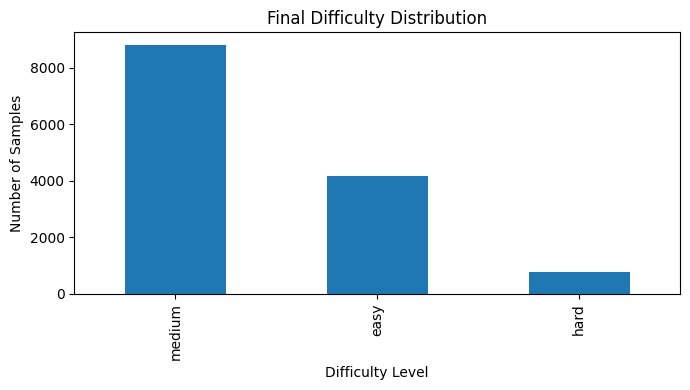

In [185]:
ax = df_clean["difficulty_clean"].value_counts().plot(
    kind="bar",
    figsize=(7, 4)
)

ax.set_title("Final Difficulty Distribution")
ax.set_xlabel("Difficulty Level")
ax.set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

fig = ax.get_figure()
fig.savefig("difficulty_distribution.png", bbox_inches="tight")

## 6.4 Conversational Formatting

The dataset is converted into a Qwen-compatible conversational format while preserving both reasoning-heavy and concise response examples.

In [186]:
# Format samples using a Qwen-compatible chat template

def format_prompt(row):

    return f"""<|im_start|>system
You are an expert assistant in quantitative finance, actuarial science, and financial risk analysis.

Provide accurate, concise, and well-structured answers.

When solving quantitative problems, clearly state assumptions, formulas, and calculations when relevant.
<|im_end|>

<|im_start|>user
{row["instruction"]}
<|im_end|>

<|im_start|>assistant
{row["response"]}
<|im_end|>
"""


In [187]:
# Apply conversational formatting to train and test subsets

df_train["text"] = df_train.apply(
    format_prompt,
    axis=1
)

df_test["text"] = df_test.apply(
    format_prompt,
    axis=1
)


train_sft = df_train[["text"]].copy()

test_sft = df_test[["text"]].copy()


## 6.5 Dataset Card Summary

- Source: `heladell/Finance_DeepSeek-R1-Distill-dataset`
- Language: English
- Domain: finance, actuarial science, and quantitative reasoning
- Training format: Qwen-compatible conversational SFT format
- Split strategy: stratified train/test split
- Main filtering criteria:
  - task category
  - language
  - finance relevance
  - reasoning-quality heuristics
- Known limitations:
  - keyword-based finance filtering
  - possible noisy reasoning traces
  - teacher-model bias inherited from distilled responses
- Training objective: conversational supervised fine-tuning
- Exported datasets:
  - JSONL files for downstream fine-tuning
  - Parquet files for inspection and reproducibility
- Visual diagnostics:
  - `dataset_filtering_pipeline.png`
  - `dataset_retention_rate.png`
  - `finance_filtering_heatmap.png`
  - `reasoning_quality_distribution.png`
  - `final_reasoning_proportion.png`
  - `difficulty_distribution.png`
- Reporting artifacts:
  - `preprocessing_report.csv`
  - `finance_filtering_table.csv`
  - `reasoning_quality_table.csv`

## 6.6 Dataset Export

The `.jsonl` files are used for downstream fine-tuning pipelines.

The `.parquet` files are preserved for reproducibility, inspection, and reporting.

In [188]:
# Export SFT datasets in JSONL format

train_sft.to_json(
    "train_sft.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)

test_sft.to_json(
    "test_sft.jsonl",
    orient="records",
    lines=True,
    force_ascii=False
)


In [189]:
# Export intermediate datasets in Parquet format

df_filtered.to_parquet(
    "df_filtered.parquet",
    index=False
)

df_clean.to_parquet(
    "df_clean.parquet",
    index=False
)

df_train.to_parquet(
    "df_train.parquet",
    index=False
)

df_test.to_parquet(
    "df_test.parquet",
    index=False
)

print("Datasets successfully exported.")

Datasets successfully exported.


In [190]:
# Reporting
stats_df.to_csv("preprocessing_report.csv", index=False)
finance_filtering_table.to_csv("finance_filtering_table.csv")
reasoning_quality_table.to_csv("reasoning_quality_table.csv")

In [191]:
from google.colab import files

# Download exported datasets and intermediate artifacts

files.download("train_sft.jsonl")
files.download("test_sft.jsonl")

files.download("df_filtered.parquet")
files.download("df_clean.parquet")
files.download("df_train.parquet")
files.download("df_test.parquet")

# Reporting
files.download("dataset_filtering_pipeline.png")
files.download("dataset_retention_rate.png")
files.download("finance_filtering_heatmap.png")
files.download("reasoning_quality_distribution.png")
files.download("final_reasoning_proportion.png")
files.download("difficulty_distribution.png")
files.download("preprocessing_report.csv")
files.download("finance_filtering_table.csv")
files.download("reasoning_quality_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 7. Conclusion

This notebook implemented a complete data preparation pipeline for a finance-oriented conversational training dataset.

The workflow combined:
- exploratory diagnostics
- domain-specific filtering
- reasoning-quality filtering
- stratified train/test splitting
- conversational formatting
- dataset export preparation

The final dataset is structured for downstream supervised fine-tuning workflows while preserving both concise responses and higher-quality reasoning examples.

## Next Steps

The next stages of the project include:
- fine-tuning the target model using the exported SFT datasets
- evaluating performance on finance and quantitative reasoning tasks
- comparing outputs against the base model
- assessing hallucination rate, reasoning quality, and response consistency

# 8. Limitations and Future Improvements

Current limitations include:
- keyword-based finance filtering
- heuristic reasoning-quality evaluation
- potential teacher-model bias
- absence of semantic relevance scoring
- no human annotation was used to validate the full dataset

Possible improvements:
- embedding-based semantic filtering
- toxicity and hallucination filtering
- perplexity-based quality scoring
- automatic duplicate detection using embeddings
- human evaluation of reasoning quality